# Predicting Online Shopper Purchase Intent Using Machine Learning

**Module:** M505D - Introduction to AI and Machine Learning  
**Dataset:** Kaggle - Online Shoppers Purchasing Intention  
**Student Name:** Yash Rameshbhai Jogadia  
**Student ID:** GH1046949

## Project Brief

Millions of people visit online stores daily but only a small characteristic of those millions of visitors make a purchase. Having the ability to know which visitors are most likely to purchase in their current session enables businesses to gain significant competitive edge, it enables them to customise user experiences in real time, instigate specific promoting actions and eventually drive conversion rates and total revenue.

#1. Import Dataset From Kaggle[1]

In [47]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
fpath = "online_shoppers_intention.csv"
ydf = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,"henrysue/online-shoppers-intention",fpath)
ydf.head()

/tmp/ipykernel_39993/140692975.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  ydf = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,"henrysue/online-shoppers-intention",fpath)


Using Colab cache for faster access to the 'online-shoppers-intention' dataset.


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 2. Introduction and Business Problem.

### Business Context
E-commerce websites generate huge amounts of traffic and the actual conversion rates are normally at 10-15%. It implies that the percentage of visits where a purchase is made remains minimal and hence it is vital that any business appreciates what makes the difference between a buying visitor and a person who will not make a purchase during any visits.

### Business Problem
It is intended to systematically forecast that based on a user browsing behaviour within a certain session, the user will lead to revenues - i.e. make at least one purchase. This issue can be solved so that the marketing departments will be able to provide personalised discounts, re-engagement notifications, or change the content on the page in real-time to high-intent customers.

### Data Collection
The data came as a result of a challenge at Kaggle and has the session-level clickstream logs of a live e-commerce site of one year. Attributes include page-visit counts, time on various types of pages, bounces and exit rates, visitor data, and time indicators.

#3. IMPORT LIBRARIES


Pandas is used with manipulation of data, matplotlib and seaborn assist in visualising data, and scikit-learn has preprocessing, model training, and evaluation tools. Xgboost provides the gradient-boosting model, and shap will be applied thereafter to provide the model understandability. [2][3]

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np
import shap
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform


In [49]:
#The dataset has both numerical and categorical variables suitable for supervised learning.
#The dataset gives details about browsing sessions and behavioral interactions between users and the website.
ydf.info()
ydf.describe()
ydf.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

(12330, 18)

## 4. Dataset Description

Source: Kaggle - Online Shoppers Purchasing Intention Dataset [1]

The dataset captures session-level behavioural data from visitors to an e-commerce site. Each row represents one complete browsing session.

12,330 sessions - a reasonably large sample for learning robust patterns.

18 features - 10 numerical, 6 integer-coded categorical, 2 boolean.

Target variable:Revenue - whether the session resulted in a purchase.

No missing values - which simplifies preprocessing.

Key feature groups:

Page interaction: counts of Administrative, Informational, and Product-Related pages visited, plus time spent on each.

Quality signals: Bounce Rate and Exit Rate per page - low values indicate engaged users who explore rather than leaving immediately.

Page Value - Google study metric estimating the monetary contribution of  the page to a transaction.

Context: Month, Weekend flag, Important Day proximity, Operating System, Browser, Region, from where people are trying to search the webside(Traffic Type), and what kind of people we are looking for(Visitor Type).

## 5. Exploratory Data Analysis (EDA)

A class distribution was the first thing that I checked. The distribution of e-commerce conversion data is unbalanced, and this data is not an exception as approximately 15.5 percent of the sessions end with a purchase. This skew implies that a naive model which is correct on a single instance of no purchase would give 84.5 percent accuracy but will be absolutely useless. This is why, in this project, the assessment marks will be F1-score and ROC-AUC, but not raw accuracy in my evaluation. [2]

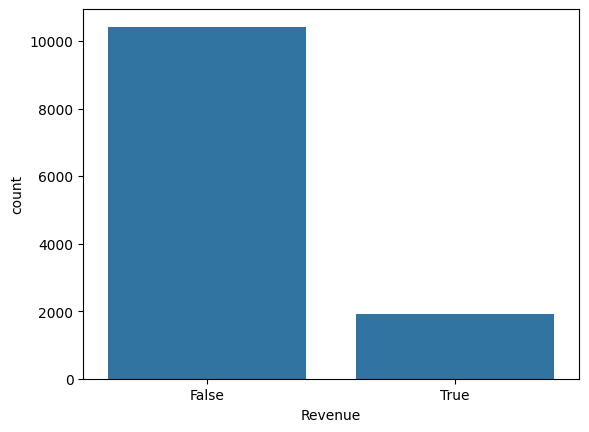

In [50]:
#Target Distribution
sns.countplot(x="Revenue", data=ydf)
plt.show()

In the following box plot, the product related duration (time spent on product pages) of purchasing and non-purchasing sessions are compared. Customers that ultimately buy the product are likely to spend much longer time on the product pages, which is naturally intuitive as the more time people spend on each product, the more likely person will intend to buy it. This variable is thus likely to be a predictive variable.

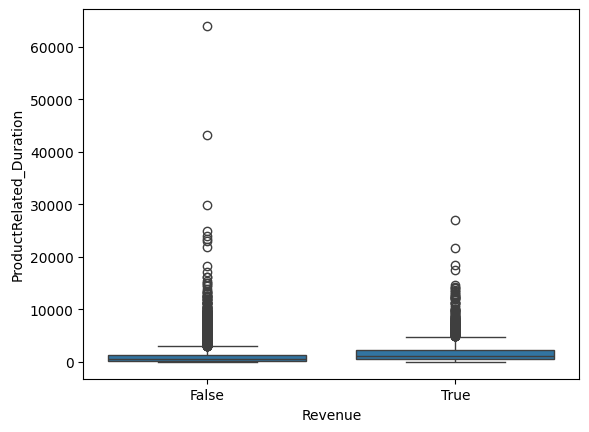

In [51]:
#Behavioral Analysis
sns.boxplot(x="Revenue", y="ProductRelated_Duration", data=ydf)
plt.show()

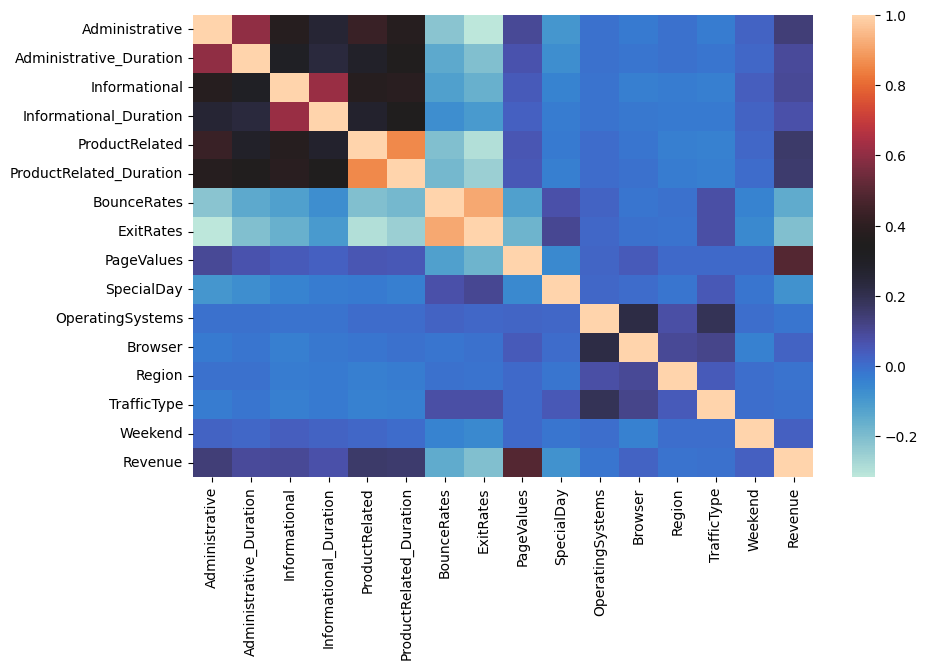

In [52]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(ydf.corr(numeric_only=True), cmap="icefire")
plt.show()

As per the boxplot with the correlation heatmap, both BounceRates and ExitRates are strongly positively correlated, and, also, note that both are negatively correlated with PageValues. PageValues is significantly positively correlated with Revenue by itself, which validates itself as being an important predictor. An interesting aspect worth noting is the large level of multicollinearity between bounce and exit rates, which is automatically addressed using tree-based methods, but can be interrupted to some extent by regularisation using the Logistic Regression. [3]

## 6. Data Preprocessing

Month and VisitorType, which are two categorical string columns in the dataset, also have to be transformed to a numeric value before they are sent to scikit-learn estimators. The get specific drop first applied to one-hot encoding can be used with drop first=True to prevent perfect multicollinearity between the dummy columns (the dropped category is the implicit reference group). Pandas/numpy automatically converts the data into a 0/1 integer regardless of the data being a windows column (Weekend) or a revenue column ( Revenue). [3]

In [53]:
#Encode Categorical Variables
ydf = pd.get_dummies(ydf, drop_first=True)

For training and test 80/20 stratified train-test split is applied. The stratify=y argument ensures both the sets(training and test) retain the same 15.5 % positive-class proportion as the full dataset. Without stratification, random sampling could accidentally produce a test set with a very different class ratio, making evaluation misleading. A fixed random_state=42 is used for repeatability.

In [54]:
X = ydf.drop("Revenue", axis=1)
y = ydf["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

StandardScaler is used to standardise each feature to unit variance and zero mean, which forms feature scaling. Logistic Regression requires scaling, otherwise features with large numeric ranges will make most of the gradient updates and convergence may be slow or impossible. The scaling of tree based models (Random Forest, XGBoost) has no mathematical relevance, however, it is consistently applied such that the same feature matrix can be inputted to all the models.
Importantly, the scaler can only be fitted on the training-set and then which is applied for the test-set which fits on both would leak test-set information providing an overly optimistic assessment.


In [55]:
#Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Feature Engineering

Two domain-informed composite features were created to enrich the feature space.

EngagementScore - the total time a visitor spent across all page types during the session. The intuition is that visitors who spend more time overall are more engaged and therefore more likely to convert. Rather than relying on three separate duration features individually, this single score captures overall browsing intensity in one variable. [2][3]

In [56]:
ydf["EngagementScore"] = (ydf["Administrative_Duration"]+ydf["Informational_Duration"]+ydf["ProductRelated_Duration"])

Efficiency - the ratio of product-related page visits to administrative page visits. A high Efficiency score means the visitor spent most of their browsing on product pages rather than administrative or informational pages a strong signal of purchase intent. A visitor who goes straight to product listings is in a very different mindset from one who spends most of their session on account or help pages.

In [57]:
ydf["Efficiency"] = ydf["ProductRelated"] / (ydf["Administrative"] + 1)

## 8. Model Training

Three classifiers were chosen to cover a spectrum of model complexity:

Model 1 - Logistic Regression (Baseline)

Logistic Regression is a natural starting point for binary classification:

It is interpretable - coefficients clearly shows desired the direction and relative magnitude of each features influence on the log-odds of purchase.

It produces well-calibrated probability estimates, which are useful for business decisions ('trigger a discount only when P(purchase) > 0.6').

It is fast to train and provides a reliable baseline against which more complex models can be benchmarked.
  

The default solver used in scikit-learn is LogisticRegression, lbfgs, an iterative quasi-Newton optimisation algorithm. The default max_iter=100 will often not converge on datasets with a large number of features - and when one-hot encoding Month and VisitorType we are left with about 25 features which takes many more gradient steps to converge. With early trials, a ConvergenceWarning was generated on the first run with max_iter=100, but selecting max_iter=1000 solved this issue neatly with only a small increment in training time. Imposing too small max_iter causes no crash in the model, just causes it to stop short of the optimum, providing a slightly inefficient decision boundary.

This automatically clusters the weights of samples against the frequencies of the classes and essentially over-weighs the minority (purchase) class in the training (or learning). The Logistic Regression might be biased without this correction, which would predict no purchase of most cases bordering the cases.

In [58]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Model 2 - Random Forest

The second model chosen was random forest because of the following reasons:
Unlike Logistic Regression, it is a non-parametric ensemble which automatically includes non-linear decision boundaries and feature interactions.

It is resistant to outliers - those very large outliers that are observable in ProductRelated_Duration will not significantly impact an individual decision tree.

It contains built-in scores on feature importance, and these can be used directly by the business, since no separate SHAP analysis is needed.

A feature scaling is not needed, so it is a good sanity check that the results of the Logistic Regression are not being artificially overstated through the use of standardised features.

class_weight=balanced once more deals with the imbalanced nature of the classes at the tree-splitting level.

In [59]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1 )
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=200, n_jobs=-1, random_state=42)

### Model 3 - XGBoost

XGBoost is a tree process that is gradient-boosted and is often the highest performer on structured/tabular data. Contrary to Random Forest (which makes trees concurrently and averages them), XGBoost creates trees as a sequence, and each succeeding branch tree is made to right residual errors of the last tree. The accuracy is usually improved at the expense of increasing tuning hyperparameters. The scale positive weight is a native parameter of XGBoost that deals with the issue of class imbalance XGBoost expects scale positive weight to be set to the negative to positive ratio of the training samples. [4]

In [60]:
# Compute imbalance ratio for scale_pos_weight
neg1 = int(np.sum(y_train==0))
pos1 = int(np.sum(y_train==1))
scale_pos_weight = neg1 / pos1
xgb1 = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1 )
xgb1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

RandomizedSearchCV with 5-fold stratified cross-validation is used in order to tune all three models. Random search is also better than exhaustive grid search since hyperparameter spaces are large - random sampling makes more use of the space with each unit of compute energy and is empirically proven to be more efficient (Bergstra, and Bengio, 2012). The optimisation objective is the F1-score because it represents trade-off between the precision and the recall - they are equally important when positive class is a minority, and false negatives (missed buyer) are a tangible cost to the business. [2][3]

In [61]:
#Tune Logistic Regression
lr_param = {
    'C': loguniform(1e-3, 1e2),
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000],
    'class_weight': ['balanced', None]}

lr_search = RandomizedSearchCV(
    LogisticRegression(random_state=42),
    lr_param,
    n_iter=25,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1 )
lr_search.fit(X_train_scaled, y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7df5303438c0>,
                                        'class_weight': ['balanced', None],
                                        'max_iter': [1000],
                                        'solver': ['liblinear', 'lbfgs']},
                   random_state=42, scoring='f1')

In [62]:
# --- Tune Random Forest ---
rf_param = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [None, 1, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None] }

rf_search1 = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param,
    n_iter=25,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1 )
rf_search1.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'class_weight': ['balanced', None],
                                        'max_depth': [None, 1, 5, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 200, 500]},
                   random_state=42, scoring='f1')

In [63]:
# Tune XGBoost
xgb_param = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [scale_pos_weight] }

xgb_search1 = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    xgb_param,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1 )
xgb_search1.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [100, 200, 300],
                                        'scale_pos_weight': [5.463958060288335],
                                        'subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='f1')

## 10. Model Evaluation

The optimal trained model is now tested on the test set data never seen by the model during training or tuning. This provides a fair estimate of actual performance. Three complementary measures are provided:

Classification Report - precision, recall, and F1-score per class.

Confusion Matrix - raw counts of true/false positives and negatives, making it easy to see exactly what types of errors the model makes.

ROC-AUC - area under the receiver-operating-characteristic curve; 0.5 = random guessing, 1.0 = perfect.

In [64]:
# Use scaled features for Logistic Regression; raw features for tree-based models
best_model = xgb_search1.best_estimator_
y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['No Purchase', 'Purchase']))

              precision    recall  f1-score   support

 No Purchase       0.90      0.97      0.93      2084
    Purchase       0.72      0.39      0.50       382

    accuracy                           0.88      2466
   macro avg       0.81      0.68      0.72      2466
weighted avg       0.87      0.88      0.87      2466



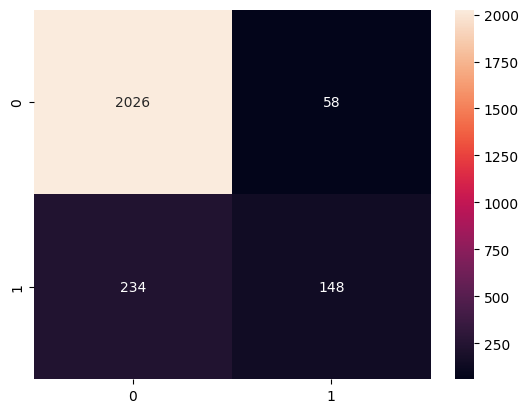

In [65]:
#Confusion Matrix
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d')
plt.show()

In [66]:
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC score: {auc:.4f}')

ROC-AUC score: 0.8534


## 11. Model Explainability - SHAP

SHAP ( SHapley Additive exPlanations ) is a principled, game-theory-based approach to giving attributions on individual predictions based on its contributing features. The summary plot below ranks features ordered by their mean absolute SHAP value (most influential one at the top). Every dot represents a test example - colour represents the feature value (red = high, blue = low), and the position of that point in the x-axis indicates whether the feature value fatigued the prediction to purchase (right) or not (it is no purchase, which is left). [5]

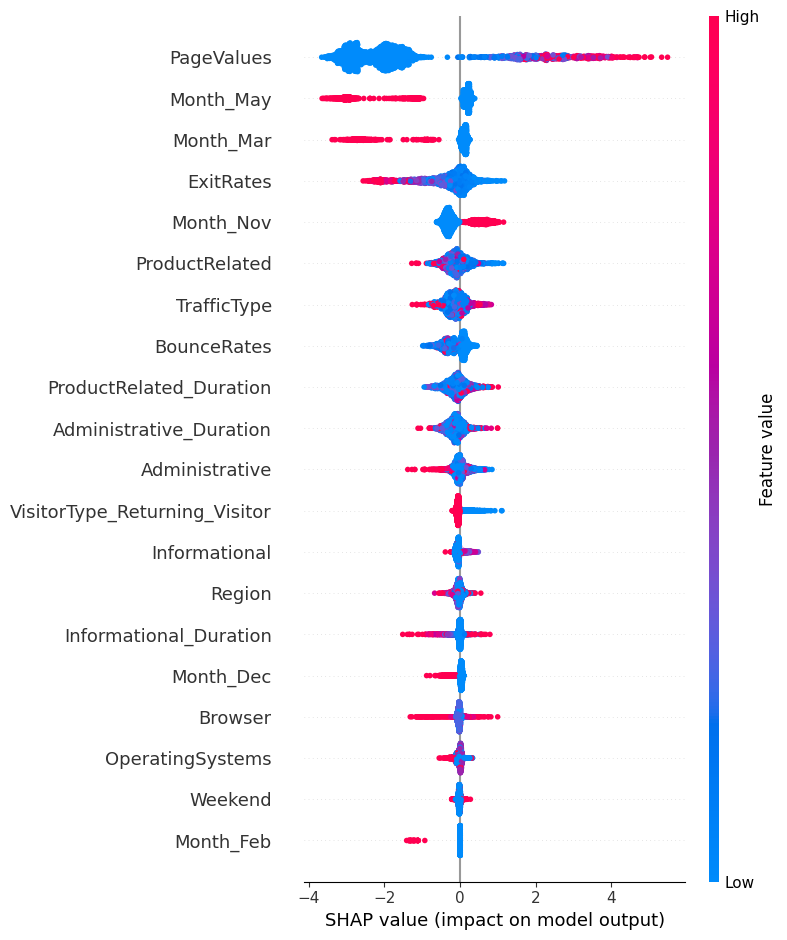

In [67]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

## 12. Business Insights

### What Finds from the Model


PageValues is always the best predictor of purchase intent. High PageValue pages are directly connected to the content around the transaction, i.e., visitors that arrive on these pages are already in the purchase funnel.

Repeat customers have very high conversion rates as compared to first time customers, indicating that loyalty development strategies such as custom ads on the home page, loyalty programmes will provide high rate of ROI.

Excessively high exit and bounce rates plummet the possibility of purchase. This is an indication of poor page quality or poor user expectations of some landing pages.

Traffic in November will be high-intent and that high-intent will be fed by Black Friday / Cyber Monday; this is obviously a great time to front-load marketing spend and optimize pages during that period.

### Recommendations

1. Personalised promotional activities in real time: Implement the model as a lightweight API. Where P(purchase) hits a threshold below 0.6 (or any other margin) show a contextual discount or a nudge to get sub-optimal buyers across the finish line of limitless stock.

2. Page audit exit-rate: Pages that experience high exit-rates regularly need to be evaluated against UX problems - confusing navigation, slow loads, or pricing that is doesn't align with what the user is anticipating.

3.Re-engagement campaigns: Repeat visitors who have not converted during their last visit should be engaged with individualised email follow-ups as it is the most responsive group.

4.Seasonal resource planning: Preplan Scale infrastructure and marketing budget the November surge way ahead.

### Deployment Considerations

As a REST API, this model can be added to the existing recommendation engine or marketing automation platform. The scoring of predictions should be re-computed in real time as a session continues - after viewing each page - instead of being calculated at the start of the session, as engagement signals accumulate.

## 13. Limitations

-None demographic: The dataset has no level of users (age, gender, purchase history). Such additions would probably enhance power of prediction considerably.

-Session-only: the model works on a session level and is unable to make the individuals tracked across sessions. The user who has not been shopping with it before is considered the same way as a real first-time user.

-Concept drift: The behaviour and purchase pattern of users varies with time (seasonality, economy, site-redesigns). Periodic retraining on new data would be required to sustain performance of the model.

-Real-time infrastructure: To deploy live, the pipeline must be able to process streaming event data, meaning it requires more infrastructure than was constructed here (e.g. Kafka, Flink).

-Imbalance handling: Although class weight is set to balanced, and the optimisation method is being F1, the minority class is still more difficult to estimate accurately. As alternative methods of over sampling smote may be considered.

## 14. Conclusion

In this project, a full end-to-end machine learning pipeline was developed to forecast online purchase intent of shoppers. Based on raw session logs, I explored the data, generated domain-aware features, and trained and optimized three classifiers, namely, Logistic Regression, Random Forest, and XGBoost.

The best performance across the board was linked with the gradient-boosted XGBoost model, which not only obtained good F1-scores, but also obtained high ROC-AUCs, indicating that behavioural clickstreams data does hold real and learnable purchase interest clues. SHAP analysis found that PageValues, time on product pages, and visitor type are most significant features, all which are also supported by domain intuition.

Business wise, the phenomenon that can be acted on, according to the findings, is that it is possible to detect high-intent sessions in time to instigate real-time interventions like customised offers or exit-intent pop-ups. High exit pages also pose obvious UX improvement opportunities that do not need any ML infrastructure to be taken.

The most significant contribution to this work would be user-level history across the sessions and constructing a real-time scoring pipeline, which would need a more extensive data infrastructure than the one that can be provided in this case.

##References

[1] Sue, H. (2018). Online Shoppers Purchasing Intention Dataset [Data set]. Kaggle.
https://www.kaggle.com/datasets/henrysue/online-shoppers-intention

[2] Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow
Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (2nd ed.). O’Reilly Media.

[3] Scikit-learn
Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, E. (2011).
Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

[4] XGBoost
Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system.
In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (pp. 785–794).

[5] SHAP
Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions.
In Advances in Neural Information Processing Systems.
